In [1]:
4

4

In [2]:
using Revise
using SSMCMain, SSMCMain.ModifiedMiCRM
includet("loading_extracted_micrm_params.jl")

using OhMyThreads
using HDF5
using LinearAlgebra

In [3]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

In [4]:
dir  = "micrm_params_used";

# Looking at one file

In [5]:
GC.gc()
empty!(Out)
GC.gc()

In [10]:
file = "Simple_environment_S150.h5"
fbasename = splitext(file)[1]
f = load_micrm_file(joinpath(dir, file));
df = micrm_dataframe(f)
df = df[df.clean, :];   # failed wells carry NaN in u_ss
df.Ns = getindex.(get_Ns.(df.params), 1)

@show nrow(df)
df[1:5, Not(:params, :u_ss)]

nrow(df) = 280

Row,well,clean,m,Ns
,String,Bool,Float64,Int64
1,W0,true,8.65923,180
2,W2,true,7.20297,180
3,W3,true,5.82597,180
4,W4,true,5.50779,180
5,W5,true,9.33432,180


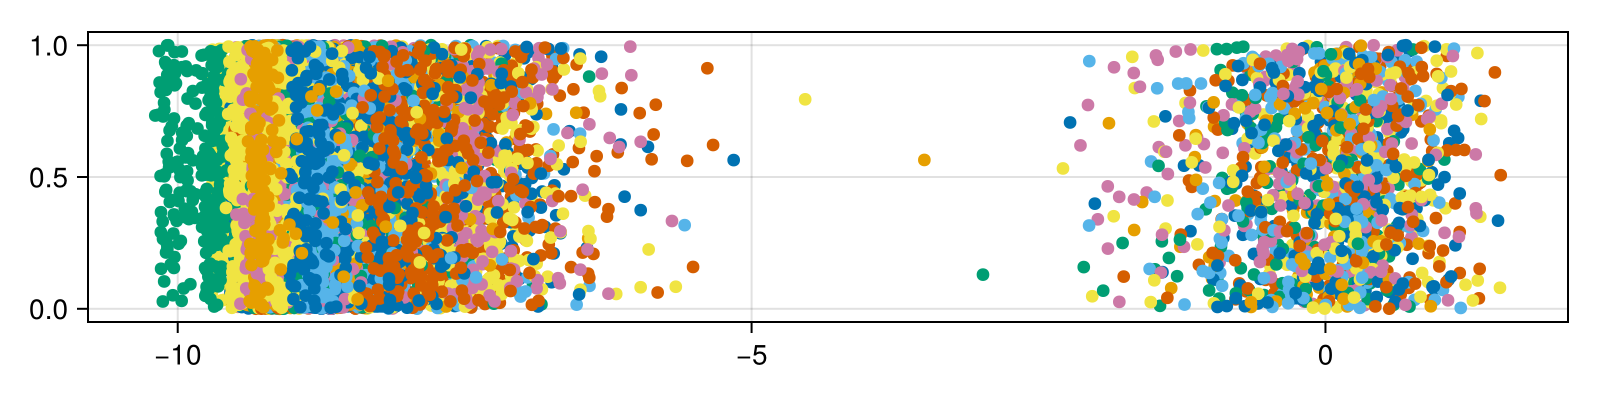

In [11]:
Ns = size(f.c, 1)   # df no longer carries a `strains` column; all strains kept

fig = Figure(;
    size=(800, 200),
)
ax = Axis(fig[1,1])
for i in 1:min(nrow(df), 100)
    r = df[i,:]
    xx = filter(!iszero, r.u_ss[1:Ns])
    scatter!(ax, log10.(xx), rand(length(xx));
    )
end
fig

In [12]:
ext_thresh = 1e-5

1.0e-5

In [13]:
@time reduced = map(eachrow(df)) do r
    rr = reduce_extinct(r.params, r.u_ss, ext_thresh)
    (rr.params, rr.final_state)
end
rdf = copy(df)
rdf.params = getindex.(reduced, 1)
rdf.u_ss = getindex.(reduced, 2)
rdf.Ns = getindex.(get_Ns.(rdf.params), 1);

  1.274735 seconds (55.09 k allocations: 244.109 MiB, 54.85% gc time, 4.63% compilation time)

In [19]:
DN = 0.0
DI = 1.0
p  = 1e0
ks = 10 .^ range(-4, 5; length=100);

In [20]:
# mrls for every row: Ds is DN on the strains, DI on the influx resources,
# p * DI on the rest (K can differ well to well, so Ds is built per row)
BLAS.set_num_threads(1)   # the rows are threaded, don't oversubscribe

mrls = Vector{Vector{Float64}}(undef, nrow(rdf))
@time @tasks for i in 1:nrow(rdf)
    pk = rdf.params[i]
    Ns, Nr = get_Ns(pk)
    Ds = vcat(fill(DN, Ns), fill(p * DI, Nr))
    Ds[Ns .+ findall(!iszero, pk.K)] .= DI
    mrls[i] = linstab_simple(pk, Ds, rdf.u_ss[i], ks)
end
rdf.mrls = mrls

(influx_resources = findall(!iszero, rdf.params[1].K),
max_mrl_over_all = maximum(maximum, rdf.mrls),
unstable_rows    = count(r -> maximum(r) > 1000eps(), rdf.mrls))

  5.764741 seconds (444.42 k allocations: 1.221 GiB, 0.84% gc time, 5.10% compilation time)

(influx_resources = [1], max_mrl_over_all = 4.637650556683945e-6, unstable_rows = 280)

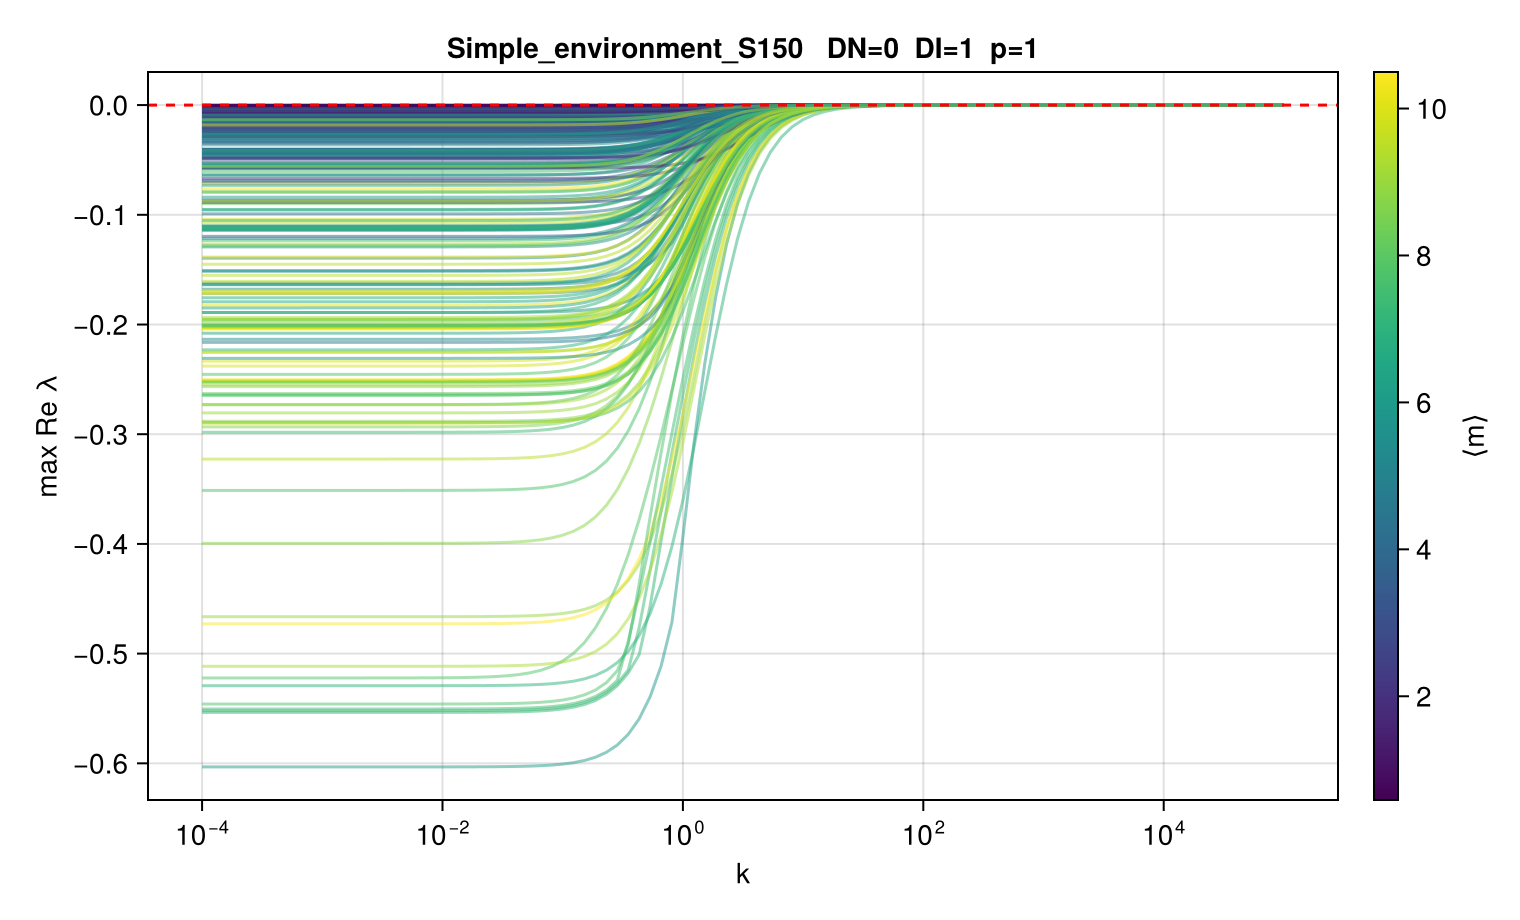

In [21]:
crange = extrema(rdf.m)

fig = Figure(size=(760, 460))
ax = Axis(fig[1, 1];
    xscale=log10, xlabel="k", ylabel="max Re λ",
    title=(@sprintf "%s   DN=%.3g  DI=%.3g  p=%.3g" fbasename DN DI p))

for row in eachrow(rdf)
    lines!(ax, ks, row.mrls;
        color=row.m, colorrange=crange, colormap=:viridis, alpha=0.5)
end
hlines!(ax, [0.0]; color=:red, linestyle=:dash)

Colorbar(fig[1, 2]; limits=crange, colormap=:viridis, label="⟨m⟩")

Makie.save(joinpath("linstab_plots", fbasename*(@sprintf "p_%.5f.pdf" p)), fig)

fig

In [47]:
display(GLMakie.Screen(), fig)

GLMakie.Screen(...)